In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d

# Model definitions
MODELS = {
    "ST_PST19": dict(file="datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra23: ST+PDT"),
    "ST_PST":   dict(file="datafiles/ST_PST",   color="tab:orange", label="Vinciguerra23: ST+PST"),
    "PDT_U":    dict(file="datafiles/PDT_U",    color="tab:green",  label="Vinciguerra23: PDT--U"),
    "ST_U":     dict(file="datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra23: ST--U"),
    "2spot":    dict(file="datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
}

# constants
G = 6.67430e-11        # m^3 kg^-1 s^-2
c = 2.99792458e8      # m s^-1
M_sun = 1.98847e30    # kg

# Load Data and compute compactness
compactness = {}
KDEs_1D = {}
C_med = {}
C_lo = {}
C_hi = {}
for key, meta in MODELS.items():
    filename = meta["file"]

    data = np.loadtxt(filename)
    M, R = data.T[0], data.T[1]

    # Unit conversions
    M_si = M * M_sun     # solar masses → kg
    R_si = R * 1e3       # km → m

    # Compactness C = GM / (Rc^2)
    C = G * M_si / (R_si * c**2)
    compactness[key] = C

    # Summary statistics
    C_med[key] = np.median(C)
    C_lo[key] = np.min(C)
    C_hi[key] = np.max(C)
    

    print(
        rf"{meta['label']}: "
        rf"${C_med[key]:.4f}^{{+{C_hi[key]:.4f}}}_{{-{C_lo[key]:.4f}}}$"
    )

    # KDE
    KDEs_1D[key] = gaussian_kde(C, bw_method="silverman")


# ------------------------------------------------------------
# Evaluate KDEs on common grid
# ------------------------------------------------------------
C_grid = np.linspace(0.08, 0.26, 400)

KDE_grid_values = {}
for key, kde in KDEs_1D.items():
    pdf = kde.evaluate(C_grid)
    KDE_grid_values[key] = pdf / np.trapz(pdf, C_grid)  # normalize

Riley19: ST+PST: $0.1533^{+0.1895}_{-0.1088}$
Vinciguerra23: ST+PDT: $0.1773^{+0.1970}_{-0.1301}$
Vinciguerra23: ST+PST: $0.1880^{+0.2069}_{-0.1582}$
Vinciguerra23: PDT--U: $0.1791^{+0.2100}_{-0.1004}$
Vinciguerra23: ST--U: $0.1861^{+0.2094}_{-0.1268}$
Miller19: 2spot: $0.1603^{+0.1932}_{-0.1252}$
Miller19: 3spot: $0.1631^{+0.1962}_{-0.1250}$


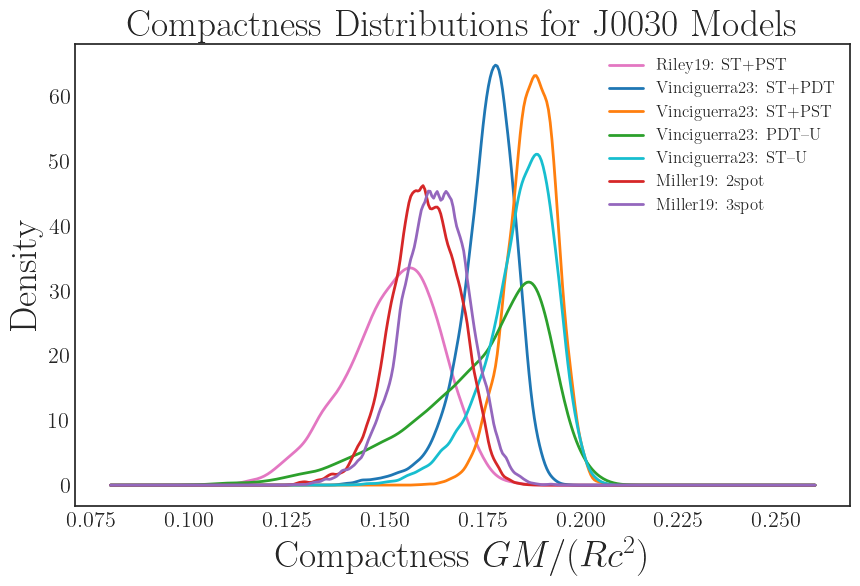

In [6]:
# Plot
plt.style.use("seaborn-v0_8-white")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

fig, ax = plt.subplots(figsize=(10, 6))

for key, meta in MODELS.items():
    ax.plot(
        C_grid,
        KDE_grid_values[key],
        color=meta["color"],
        lw=2,
        label=meta["label"]
    )

ax.set_xlabel("Compactness $GM/(Rc^2)$", fontsize=27)
ax.set_ylabel("Density", fontsize=27)
ax.set_title("Compactness Distributions for J0030 Models", fontsize=27)

ax.tick_params(labelsize=16)
ax.legend(fontsize=12)

fig.savefig(
    "/Users/ryanoconnor/Desktop/NeutronStarStuff/figures/KDECompactnessVariousModels.png",
    dpi=300
)

# plt.show()

In [ ]:
# sigma: the width of the Gaussian distribution
sigma_grid = np.logspace(-6, -0.5, 40)
prior_sigma = 1.0 / sigma_grid
prior_sigma /= np.trapz(prior_sigma, sigma_grid)

# Alpha grid
alpha_grid = np.linspace(0.01, 1.0, 40)

# Exponential prior from Bernal & Peacock
prior_alpha = np.exp(-alpha_grid)
prior_alpha /= np.trapz(prior_alpha, alpha_grid)

dC = C_grid[1] - C_grid[0]

P_C_given_sigma = []
evidence_sigma = []

# ---------------------------------------------------
# COMBINATION
# ---------------------------------------------------

for k, sigma in enumerate(sigma_grid):

    sigma_pixels = sigma / dC

    # Product over datasets
    product_likelihood = np.ones_like(C_grid)

    for key in MODELS:

        # Base KDE likelihood
        L_i = KDEs_1D[key].evaluate(C_grid)

        # Apply shift convolution
        L_i_shifted = gaussian_filter1d(L_i, sigma_pixels)

        # --- Marginalize over alpha ---
        L_alpha_marg = np.zeros_like(C_grid)

        for j, alpha in enumerate(alpha_grid):

            # Power-law rescaling
            L_alpha = L_i_shifted ** alpha

            # Renormalize after exponentiation
            L_alpha /= np.trapz(L_alpha, C_grid)

            # Weight by prior
            L_alpha_marg += L_alpha * prior_alpha[j]

        # Normalize again for numerical stability
        L_alpha_marg /= np.trapz(L_alpha_marg, C_grid)

        # Multiply into global product
        product_likelihood *= L_alpha_marg

    # Evidence for this sigma
    Z_sigma = np.trapz(product_likelihood, C_grid)
    evidence_sigma.append(Z_sigma)

    # Store normalized P(C | sigma)
    P_C_given_sigma.append(product_likelihood / Z_sigma)

P_C_given_sigma = np.array(P_C_given_sigma)
evidence_sigma = np.array(evidence_sigma)

# ---------------------------------------------------
# POSTERIOR OVER sigma_shift
# ---------------------------------------------------

posterior_sigma = evidence_sigma * prior_sigma
posterior_sigma /= np.trapz(posterior_sigma, sigma_grid)

# ---------------------------------------------------
# FINAL POSTERIOR OVER C
# ---------------------------------------------------

final_posterior = np.zeros_like(C_grid)

for k in range(len(sigma_grid)):
    final_posterior += P_C_given_sigma[k] * posterior_sigma[k]

final_posterior /= np.trapz(final_posterior, C_grid)

# ---------------------------------------------------
# SUMMARY STATISTICS
# ---------------------------------------------------

cdf = np.cumsum(final_posterior) * dC
quantiles = [0.16, 0.50, 0.84]
quantile_values = np.interp(quantiles, cdf, C_grid)

print("Final marginalized compactness constraints:")
for q, val in zip(quantiles, quantile_values):
    print(f"{int(q*100)}%: {val:.4f}")

Final marginalized compactness constraints:
16%: 0.1647
50%: 0.1718
84%: 0.1783


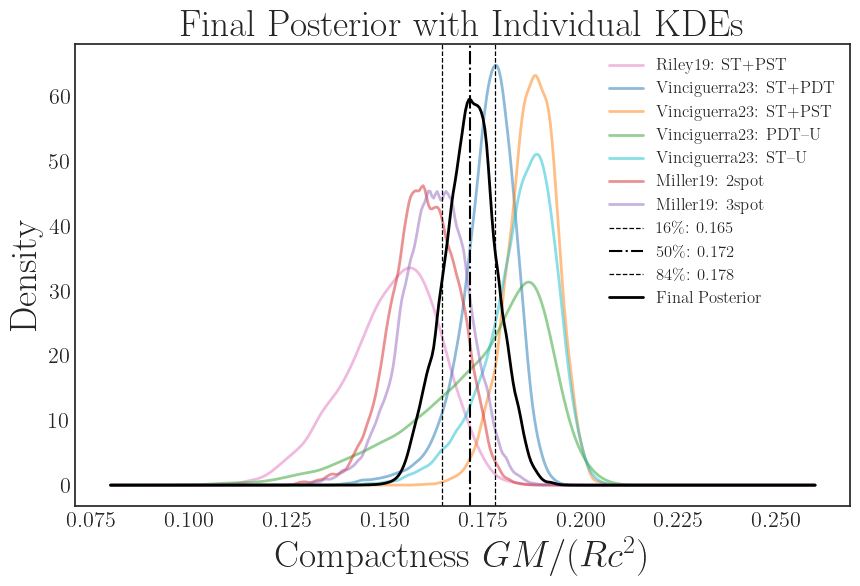

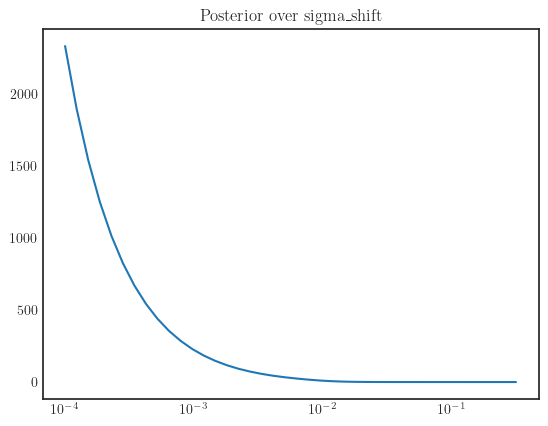

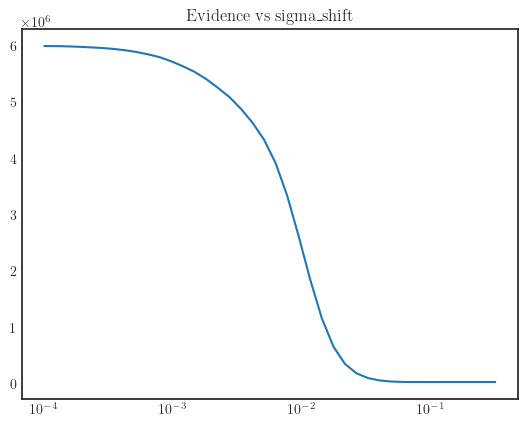

In [9]:
# Plot final posterior with individual measurements 
plt.style.use("seaborn-v0_8-white")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
fig, ax = plt.subplots(figsize=(10, 6))
for key, meta in MODELS.items():
    ax.plot(
        C_grid,
        KDE_grid_values[key],
        color=meta["color"],
        lw=2,
        alpha=0.5,
        label=meta["label"]
    )

# 16-50-84 markers
for q, val in zip(quantiles, quantile_values):
    style = "-." if q == 0.5 else "--"
    lw = 1.5 if q == 0.5 else 0.9
    ax.axvline(
        val,
        linestyle=style,
        color="black",
        linewidth=lw,
        label=rf"{int(q*100)}\%: {val:.3f}"
    )

ax.plot(C_grid, final_posterior, color="black", lw=2, alpha=1,label="Final Posterior")
ax.set_xlabel("Compactness $GM/(Rc^2)$", fontsize=27)
ax.set_ylabel("Density", fontsize=27)
ax.set_title("Final Posterior with Individual KDEs", fontsize=27)
ax.tick_params(labelsize=16)
ax.legend(fontsize=12)
plt.show()

plt.plot(sigma_grid, posterior_sigma)
plt.xscale("log")
plt.title("Posterior over sigma_shift")
plt.show()

plt.plot(sigma_grid, evidence_sigma)
plt.xscale("log")
plt.title("Evidence vs sigma_shift")
plt.show()

In [10]:
# ---------------------------------------------------
# POSTERIOR OVER alpha FOR EACH DATASET
# ---------------------------------------------------

alpha_posteriors = {}

for key in MODELS:

    print(f"Computing alpha posterior for {key}...")

    P_alpha = np.zeros_like(alpha_grid)

    for j, alpha_i in enumerate(alpha_grid):

        # Accumulate marginalized likelihood over sigma
        sigma_integral = 0.0

        for k, sigma in enumerate(sigma_grid):

            sigma_pixels = sigma / dC

            product_likelihood = np.ones_like(C_grid)

            for other_key in MODELS:

                L = KDEs_1D[other_key].evaluate(C_grid)
                L_shifted = gaussian_filter1d(L, sigma_pixels)

                if other_key == key:
                    # Fix alpha_i for this dataset
                    L_alpha = L_shifted ** alpha_i
                    L_alpha /= np.trapz(L_alpha, C_grid)
                else:
                    # Marginalize over alpha for other datasets
                    L_alpha = np.zeros_like(C_grid)

                    for m, alpha in enumerate(alpha_grid):
                        temp = L_shifted ** alpha
                        temp /= np.trapz(temp, C_grid)
                        L_alpha += temp * prior_alpha[m]

                    L_alpha /= np.trapz(L_alpha, C_grid)

                product_likelihood *= L_alpha

            Z_sigma = np.trapz(product_likelihood, C_grid)

            # Weight by posterior over sigma
            sigma_integral += Z_sigma * posterior_sigma[k]

        # Multiply by prior_alpha
        P_alpha[j] = sigma_integral * prior_alpha[j]

    # Normalize posterior
    P_alpha /= np.trapz(P_alpha, alpha_grid)

    alpha_posteriors[key] = P_alpha

Computing alpha posterior for ST_PST19...


KeyboardInterrupt: 

In [ ]:
for key in MODELS:

    P_alpha = alpha_posteriors[key]

    cdf_alpha = np.cumsum(P_alpha) * (alpha_grid[1] - alpha_grid[0])
    q_vals = np.interp([0.16, 0.5, 0.84], cdf_alpha, alpha_grid)

    print(f"\nAlpha posterior for {key}:")
    print(f"16%: {q_vals[0]:.3f}")
    print(f"50%: {q_vals[1]:.3f}")
    print(f"84%: {q_vals[2]:.3f}")

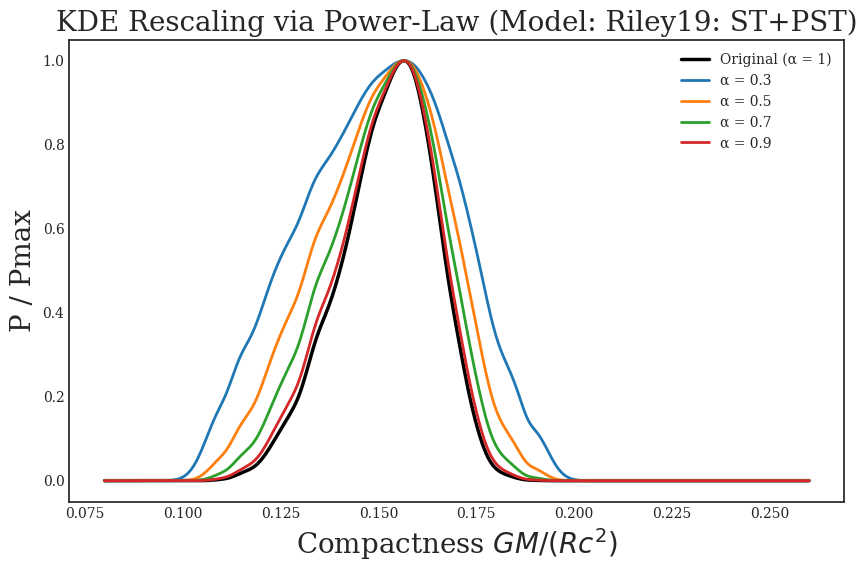

In [ ]:
# Visualization help

import numpy as np
import matplotlib.pyplot as plt

# Choose one model to visualize
example_key = list(MODELS.keys())[0]
label = MODELS[example_key]["label"]

# Evaluate original KDE
L_original = KDEs_1D[example_key].evaluate(C_grid)
L_original /= np.trapz(L_original, C_grid)

# Alpha values to test
alpha_values = [0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(10,6))

plt.rcParams.update({
    "text.usetex": False
})

# Plot original
plt.plot(C_grid,
         L_original / np.max(L_original),
         color='black',
         linewidth=2.5,
         label='Original (α = 1)')

# Plot rescaled versions
L_alpha = {}
for alpha, i in zip(alpha_values, range(len(alpha_values))):

    L_alpha[i] = L_original ** alpha
    L_alpha[i] /= np.trapz(L_alpha[i], C_grid)

    plt.plot(C_grid,
             L_alpha[i] / np.max(L_alpha[i]),
             linewidth=2,
             label=f'α = {alpha}')

plt.xlabel(r"Compactness $GM/(Rc^2)$", fontsize=20)
plt.ylabel("P / Pmax", fontsize=20)
plt.title(f"KDE Rescaling via Power-Law (Model: {label})",
          fontsize=20)

plt.legend()
plt.show()